# Plot QC improvement with added FC

1) Assembly QC overview
2) Input QC
3) Summary plots

In [29]:
library(tidyverse)
library(ggplot2)
library(ggridges)
source("../scripts/00_R_presets.R")

## 1) Assembly QC

In [3]:
qc_asm <- read_tsv("../../assembly/qc/qc_flowcells.tsv", col_type = 'cdcccc') 
head(qc_asm)


metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
mapped_sequences_n,853,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
primary_alignments_n,12985,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
secondary_alignments_n,4695,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
primary_alignments_long_cigar_n,0,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
bases_in_mapped_sequences,2865320193,haplotype1,phased_verkko,TUE_02_01UL,stat,NA
bases_mapped,2837676961,haplotype1,phased_verkko,TUE_02_01UL,stat,NA


In [4]:
n_UL = c(1,2,3,4,5,6)
n_DX = c(0,1,2)
samples = c("TUE_02")

In [5]:
combinations <- as_tibble(expand.grid("n_UL" = n_UL, "n_DX" = as.factor(n_DX), "sample" = samples)) %>%
    mutate(asm_name = ifelse(n_DX == 0,
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL"),
        paste0(sample,  "_", str_pad(n_UL, 2, pad = 0), "UL", "_", str_pad(n_DX, 2, pad = "0"), "DX")))

In [6]:
dt <- inner_join(
  combinations,
  qc_asm,
  by = join_by("asm_name"),
)

head(dt)
asm_names <- dt %>% select(asm_name, n_DX, n_UL) %>% unique()


n_UL,n_DX,sample,asm_name,metric,value,haplotype,asm_method,source,chromosome
<dbl>,<fct>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0,TUE_02,TUE_02_01UL,mapped_sequences_n,853,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,primary_alignments_n,12985,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,secondary_alignments_n,4695,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,primary_alignments_long_cigar_n,0,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,bases_in_mapped_sequences,2865320193,haplotype1,phased_verkko,stat,NA
1,0,TUE_02,TUE_02_01UL,bases_mapped,2837676961,haplotype1,phased_verkko,stat,NA


In [7]:
print(paste("Rows unprocessed:", nrow(dt)))
source("../scripts/13_process_assembly_qc.R")

dt_processed <- process_qc_table(dt) %>% mutate(haplotype = ifelse(is.na(haplotype), "both", haplotype))
print(paste("Rows processed:", nrow(dt_processed)))


[1] "Rows unprocessed: 19091"
[1] "Rows processed: 1649"


In [24]:
metrics <- dt_processed %>% 
    select('metric') %>% 
    unique() %>%
    filter(!'metric'%in% c("blocks", "variants")) %>%
    pull()

#print(metrics)

for (i in 1:length(metrics))
{
    print(paste("Plotting", metrics[i]))
    p <- ggplot(dt_processed %>% filter(metric == metrics[i]), aes(x = n_UL, y = value, col = n_DX)) +
        #geom_bar(stat = "identity",position = "dodge", col = "grey20") +
        geom_line(aes(linetype = haplotype)) +
        # Okabe-Ito palette (colorblind friendly)
        scale_colour_manual(values = c( "#E69F00", "#56B4E9", "#009E73","#999999", "#F0E442")) +
        scale_x_continuous(breaks = n_UL, minor_breaks = NULL) +  # Add tickmarks at every n_UL value
        facet_wrap(~asm_method) +
        labs(
            x = "n UL Flowcells",
            y = metrics[i],
            fill = "n DX Flowcells"
         )
    ggsave(paste0("../../doc/img/flowcells/", metrics[i], ".png"), p, width = 5, height = 3)
}

[1] "Plotting length"


[1] "Plotting ref_covered"
[1] "Plotting asm_covered"
[1] "Plotting inter-chromosomal_misjoins"
[1] "Plotting intra-chromosomal_gaps"
[1] "Plotting candidate_inversions_in_the_middle"
[1] "Plotting candidate_inversions_at_contig_ends"
[1] "Plotting variants"
[1] "Plotting blocks"
[1] "Plotting qv"
[1] "Plotting n_T2T"
[1] "Plotting total_n_count"
[1] "Plotting total_gaps"
[1] "Plotting n_contigs"
[1] "Plotting n_contigs_over_10mb"
[1] "Plotting genome_completeness"
[1] "Plotting MMC"
[1] "Plotting MSC"
[1] "Plotting overall_switch_rate"


In [25]:
# export dt to tsv file
write_tsv(dt_processed, "../../doc/tables/flowcells_qc.tsv")

## 2) Input data comparison


### 2.1) HQ reads

In [26]:
source("../scripts/02_plot_read_stats.R")

l_dt_qc <- list()
for (i in 1:nrow(asm_names)) {
    print(paste("Processing", asm_names$asm_name[i]))
    asm_prefix <- if(str_count(asm_names$asm_name[i], "_") >= 3) {
      sub("_[^_]*$", "", asm_names$asm_name[i])
    } else {
      asm_names$asm_name[i]
    }
    if (asm_names$n_DX[i] == 0) {
        if (asm_names$n_UL[i] < 3) {
            read_type <- "HQ_herro"
        } else {
            read_type <- "HQ_herro.50x"
        }
    } else if (asm_names$n_DX[i] == 1) {
        if (asm_names$n_UL[i] < 3) {
            read_type <- "HQ_combined.10x_maxx"
        } else if (asm_names$n_UL[i] == 3) {
            read_type <- "HQ_combined.10x_30x"
        } else if (asm_names$n_UL[i] == 4) {
            read_type <- "HQ_combined.10x_40x"
        } else if (asm_names$n_UL[i] == 5) {
            read_type <- "HQ_combined.10x_30x"
        } else if (asm_names$n_UL[i] == 6) {
            read_type <- "HQ_combined.10x_40x"
        } 
    } else if (asm_names$n_DX[i] == 2) {
        read_type <- "HQ_combined.maxx_maxx"
    } else {
        print("Error: n_DX is not 0, 1, or 2")
    }
    file_path <- paste0("../../assembly/input_qc/", asm_prefix,"/", asm_prefix, ".", read_type, "/read_stats.txt")
    l_dt_qc[[asm_names$asm_name[i]]] <- process_sequencing_file(file_path)
}

for (i in 1:length(l_dt_qc)) {
    l_dt_qc[[i]]$summary_stats$sample_name <- names(l_dt_qc)[i]
    l_dt_qc[[i]]$read_length_density$sample_name <- names(l_dt_qc)[i]
    l_dt_qc[[i]]$quality_density$sample_name <- names(l_dt_qc)[i]
    l_dt_qc[[i]]$density_2d$sample_name <- names(l_dt_qc)[i]
}

dt_stats_hq <- bind_rows(lapply(l_dt_qc, function(x) x$summary_stats)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_read_length_density_hq <- bind_rows(lapply(l_dt_qc, function(x) x$read_length_density)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_quality_density_hq <- bind_rows(lapply(l_dt_qc, function(x) x$quality_density)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_density_2d_hq <- bind_rows(lapply(l_dt_qc, function(x) x$density_2d)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))


KernSmooth 2.23 loaded
Copyright M. P. Wand 1997-2009



[1] "Processing TUE_02_01UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_01UL/TUE_02_01UL.HQ_herro/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in calculate_2d_density(result$plot_data):
“Skipping 2D density for sample TUE_02_01UL_HQ_herro due to insufficient variation”


[1] "Calculating read length histogram"
[1] "Processing TUE_02_02UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_02UL/TUE_02_02UL.HQ_herro/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in calculate_2d_density(result$plot_data):
“Skipping 2D density for sample TUE_02_02UL_HQ_herro due to insufficient variation”


...

[1] "Calculating read length histogram"
[1] "Processing TUE_02_04UL_02DX"
[1] "Reading file: ../../assembly/input_qc/TUE_02_04UL/TUE_02_04UL.HQ_combined.maxx_maxx/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in value[[3L]](cond):
“Zero scale estimate for y values in sample TUE_02_04UL_HQ_combined.maxx_maxx”
Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"
[1] "Processing TUE_02_06UL_02DX"
[1] "Reading file: ../../assembly/input_qc/TUE_02_06UL/TUE_02_06UL.HQ_combined.maxx_maxx/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in value[[3L]](cond):
“Zero scale estimate for y values in sample TUE_02_06UL_HQ_combined.maxx_maxx”
Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"


In [27]:
# Stats for HERRO only FC
dt_herro_stats_hq <- dt_stats_hq %>% filter(n_DX == 0)
dt_herro_stats_hq

sample_name,N50,mean_quality,median_quality,total_bases,num_reads,mean_read_length,median_read_length,yield_above_80kb,yield_above_100kb,yield_above_200kb,yield_above_500kb,reads_above_1MB,n_DX,n_UL
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<dbl>
TUE_02_01UL,30919,33,33,99467912039,4763903,20879.50,14045,10781420898,5631006439,170380854,0,0,0,1
TUE_02_02UL,44696,33,33,206846184224,7619312,27147.62,16377,55527817407,39663983054,7954448077,33566501,0,0,2
TUE_02_03UL,80466,33,33,160000022814,2066094,77440.82,64294,80618140989,56517647266,9702465035,30196590,0,0,3
TUE_02_04UL,100052,33,33,160000056144,1596243,100235.40,87421,116422827903,80077847139,12040957686,33009374,0,0,4
TUE_02_05UL,121365,33,33,160000071170,1302576,122833.58,109308,160000071170,116319428613,19323774805,81931425,0,0,5
TUE_02_06UL,129349,33,33,160000060905,1212115,132000.73,118821,160000060905,137295636350,21143673973,83289783,0,0,6


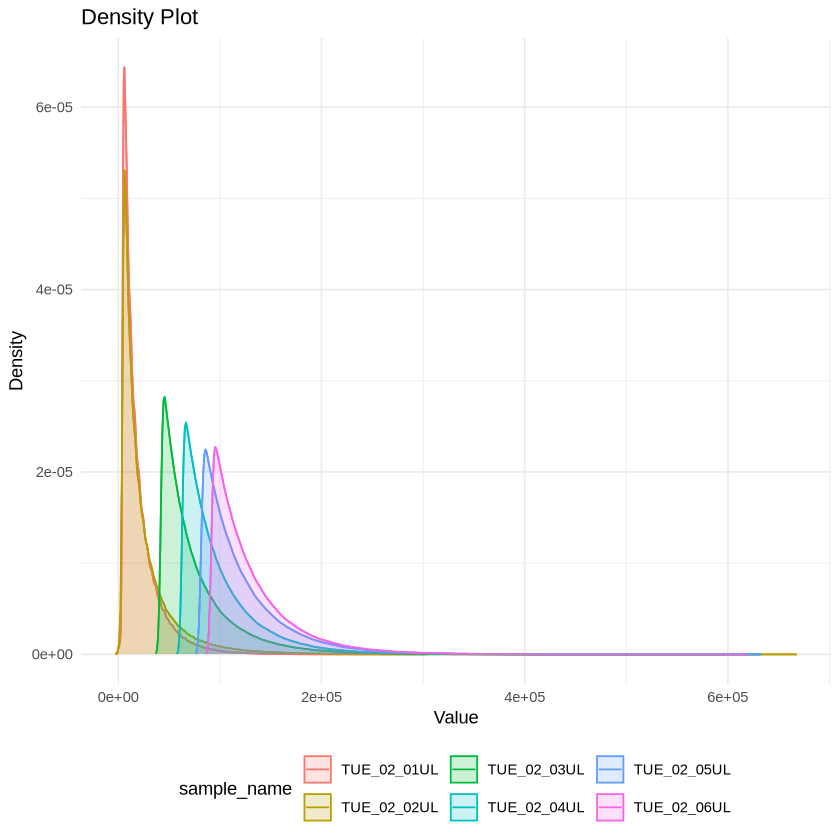

In [30]:
plot_1d_density(dt_read_length_density_hq %>% filter(n_DX == 0))

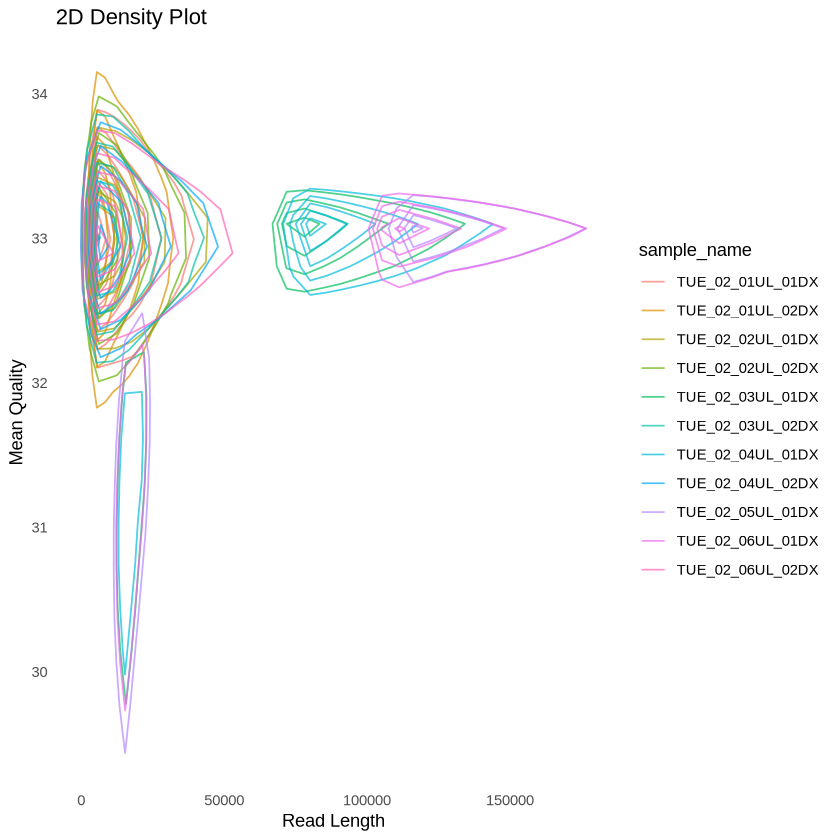

In [31]:
# 2D density plot, skewed because of HERRO scores
plot_2d_density(dt_density_2d_hq)

Interpretation of these results:
- Quality of Herro reads, based on QC scores cannot be estimated
- Using more then 4 Flowcells leads to higher input read lengths due to read subsampling.

### Compare UL reads

In [32]:
source("../scripts/02_plot_read_stats.R")
l_ul_qc <- list()
asm_names_ul <- asm_names %>% filter(n_DX == 0)
for (i in 1:nrow(asm_names_ul)) {
    print(paste("Processing", asm_names_ul$asm_name[i]))
    asm_prefix <- if(str_count(asm_names$asm_name[i], "_") >= 3) {
      sub("_[^_]*$", "", asm_names$asm_name[i])
    } else {
      asm_names$asm_name[i]
    }
    read_type <- "UL.70x"
    file_path <- paste0("../../assembly/input_qc/", asm_prefix,"/", asm_prefix, ".", read_type, "/read_stats.txt")
    l_ul_qc[[asm_names$asm_name[i]]] <- process_sequencing_file(file_path)
}

[1] "Processing TUE_02_01UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_01UL/TUE_02_01UL.UL.70x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"
[1] "Processing TUE_02_02UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_02UL/TUE_02_02UL.UL.70x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"
[1] "Processing TUE_02_03UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_03UL/TUE_02_03UL.UL.70x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


...

[1] "Calculating read length histogram"
[1] "Processing TUE_02_05UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_05UL/TUE_02_05UL.UL.70x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"
[1] "Processing TUE_02_06UL"
[1] "Reading file: ../../assembly/input_qc/TUE_02_06UL/TUE_02_06UL.UL.70x/read_stats.txt"
[1] "Calculating summary statistics"
[1] "Calculating 1D density for read length"
[1] "Calculating 1D density for mean quality"
[1] "Calculating 2D density"


Warning message in bkde2D(cbind(x_vals, y_vals), bandwidth = c(h1, h2), gridsize = c(n, :
“Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'”


[1] "Calculating read length histogram"


In [33]:
for (i in 1:length(l_ul_qc)) {
    l_ul_qc[[i]]$summary_stats$sample_name <- names(l_ul_qc)[i]
    l_ul_qc[[i]]$read_length_density$sample_name <- names(l_ul_qc)[i]
    l_ul_qc[[i]]$quality_density$sample_name <- names(l_ul_qc)[i]
    l_ul_qc[[i]]$density_2d$sample_name <- names(l_ul_qc)[i]
    l_ul_qc[[i]]$read_length_histogram$sample_name <- names(l_ul_qc)[i]
}


In [34]:
# Combine all summary statistics into a single data frame
dt_stats_ul <- bind_rows(lapply(l_ul_qc, function(x) x$summary_stats)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_read_length_density_ul <- bind_rows(lapply(l_ul_qc, function(x) x$read_length_density)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_read_length_histogram_ul <- bind_rows(lapply(l_ul_qc, function(x) x$read_length_histogram)) %>%
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_quality_density_ul <- bind_rows(lapply(l_ul_qc, function(x) x$quality_density)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))
dt_density_2d_ul <- bind_rows(lapply(l_ul_qc, function(x) x$density_2d)) %>%  
    inner_join(asm_names, by = c("sample_name" = "asm_name"))

In [35]:
dt_stats_ul

sample_name,N50,mean_quality,median_quality,total_bases,num_reads,mean_read_length,median_read_length,yield_above_80kb,yield_above_100kb,yield_above_200kb,yield_above_500kb,reads_above_1MB,n_DX,n_UL
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<dbl>
TUE_02_01UL,104503,24.24788,24.24788,12857921658,117046,109853.6,97903,12857681658,7282023712,910491134,241446276,31,0,1
TUE_02_02UL,125330,24.50965,24.50965,61810644886,488650,126492.7,109546,61809684886,45239197805,10418502528,441875142,60,0,2
TUE_02_03UL,122012,24.98229,24.98229,89135967621,720989,123630.1,108256,89134847621,63954213335,12712024242,537756923,75,0,3
TUE_02_04UL,119661,25.31760,25.31760,129613824580,1065669,121626.7,107218,129612064580,91482318050,16227909753,755310148,126,0,4
TUE_02_05UL,122701,25.53742,25.53742,182051491289,1469212,123911.0,108991,182049011289,131922972220,25324158308,1019074573,180,0,5
TUE_02_06UL,120973,25.55617,25.55617,219013768773,1786997,122559.7,108119,219010488773,156661221276,28265258604,1269155787,231,0,6


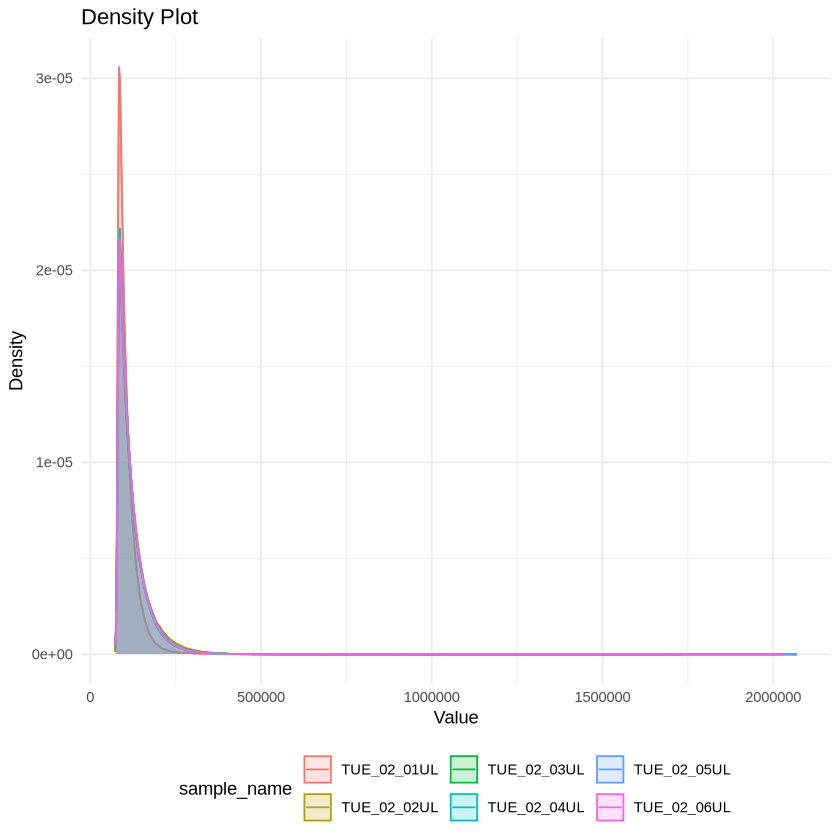

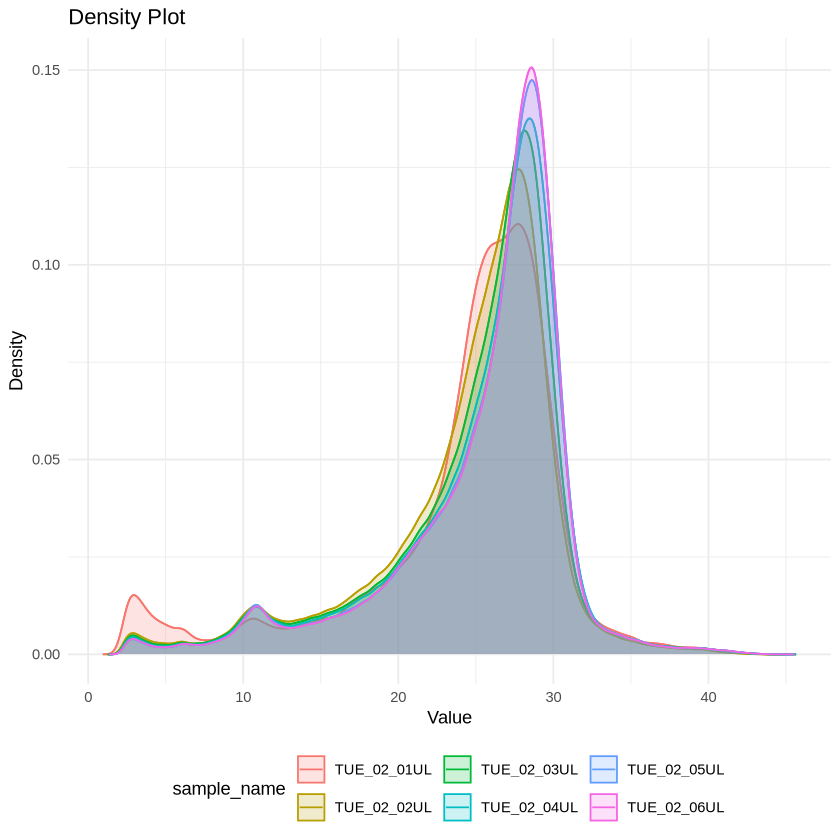

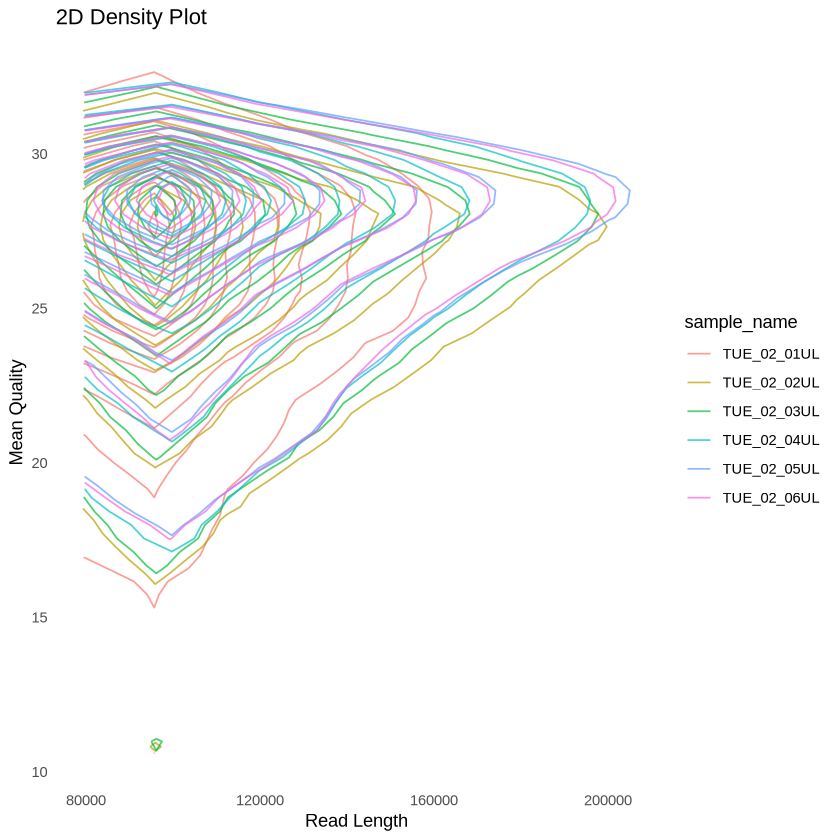

In [36]:
plot_1d_density(dt_read_length_density_ul)
plot_1d_density(dt_quality_density_ul)
plot_2d_density(dt_density_2d_ul)

# Plot read length distributions

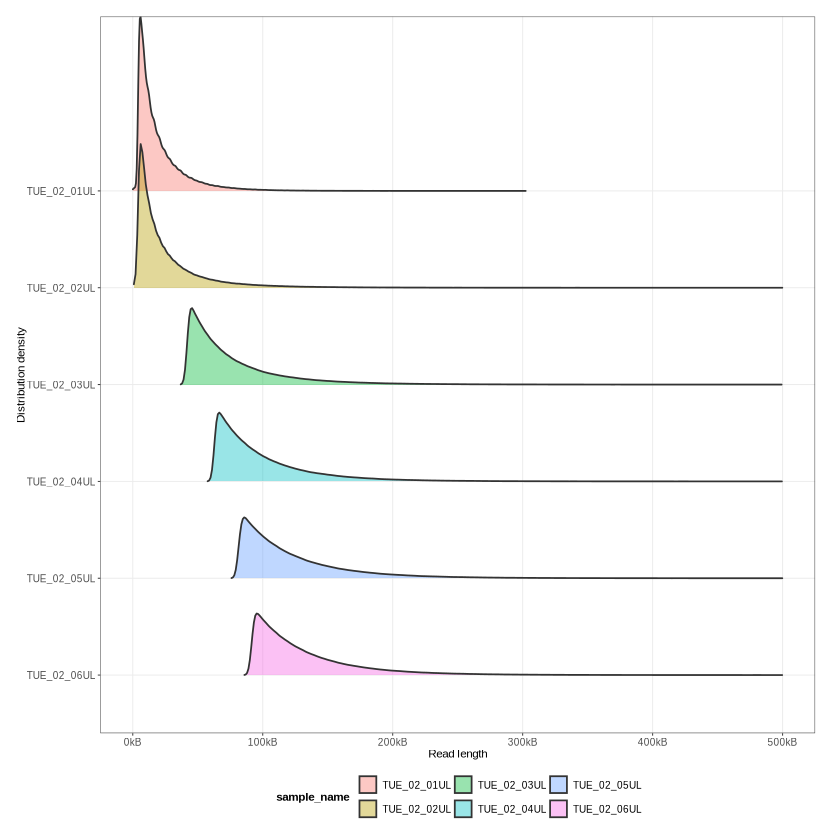

In [40]:
library(ggridges)
p_read_lengths_hq <- ggplot(dt_read_length_density_hq %>% filter(n_DX == 0), aes(x = x, y = reorder(sample_name, -n_UL), color = sample_name, fill = sample_name)) +
    geom_density_ridges(
        aes(height = y, group = sample_name),
        stat = "identity", 
        colour = "grey20",
        alpha = 0.4
    ) +
    labs(
      x = "Read length",
      y = "Distribution density"
    ) +
    scale_x_continuous(
        limits = c(0, 500000),
        breaks = seq(0, 700000, 100000), # add more as needed
        labels = str_c(seq(0, 700, 100), "kB")
    ) +
    theme(legend.position = "bottom")

p_read_lengths_hq
ggsave("../../doc/img/flowcells_read_lengths_hq.png", p_read_lengths_hq, width = 5, height = 3)


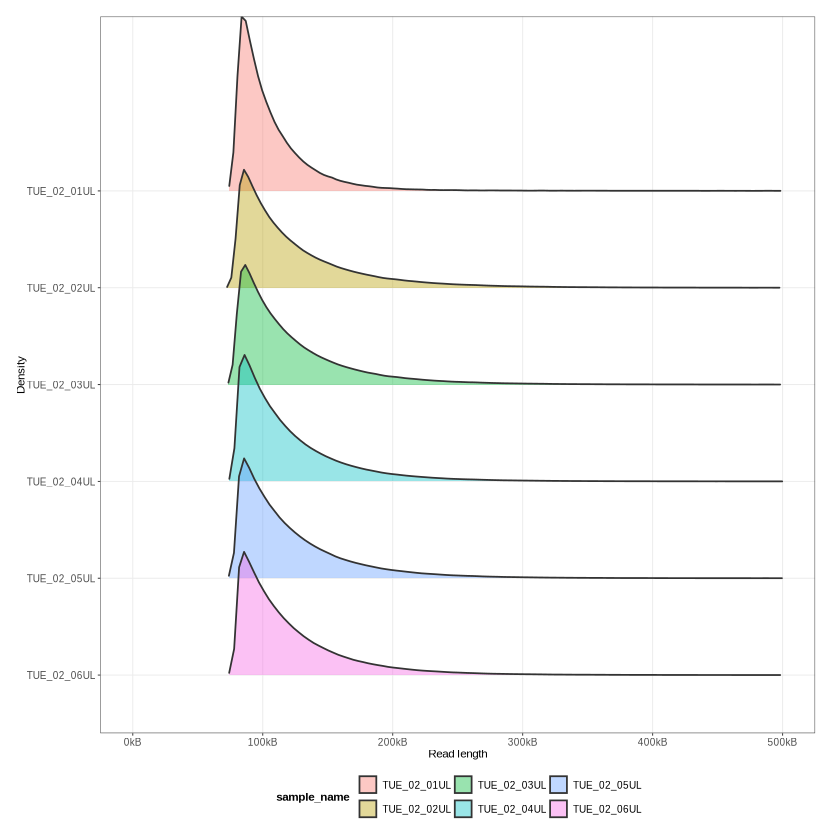

In [41]:
library(ggridges)
p_read_lengths_ul <- ggplot(dt_read_length_density_ul %>% filter(n_DX == 0), aes(x = x, y = reorder(sample_name, -n_UL), color = sample_name, fill = sample_name)) +
    geom_density_ridges(
        aes(height = y, group = sample_name),
        stat = "identity",
        colour = "grey20",
        alpha = 0.4
    ) +
    labs(
      x = "Read length",
      y = "Density"
    ) +
    scale_x_continuous(
        limits = c(0, 500000),
        breaks = seq(0, 700000, 100000), # add more as needed
        labels = str_c(seq(0, 700, 100), "kB")
    ) +
    theme(legend.position = "bottom")

p_read_lengths_ul
ggsave("../../doc/img/flowcells_read_lengths_ul.png", p_read_lengths_ul, width = 5, height = 3)